## Kerasによる基本的なRNNの実装

### ライブラリのimport

それでは演習として、KerasによるRNNモデルの実装を行ってみましょう。
まずは必要なライブラリをimportします。

In [1]:
# 必要なライブラリのimport
import numpy as np
import math
import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split

# DataFrameですべての列を表示する設定
pd.options.display.max_columns = None

# 生成する乱数を固定させる
np.random.seed(seed=0)

/Users/MisayoMacBookPro/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


### データセットの作成

今回は時系列のサンプルデータとして、「sin波」のデータを使用します。sin波は音波の基本で、「波の形状」が時系列的な前後関係を持ちます。よって「これまでの波の値」から、「次の波の値」を予測することとします。まずはsin波を生成する関数を用意します。

In [2]:
# サンプリング周波数（1秒あたりのサンプリング数）
F = 100
# 周波数
Hz = 1
# サンプリング秒数
SEC = 5

# sin波の実装
def sin(t):
    return np.sin(2.0 * np.pi * (t * Hz) / F)  #np.pi=円周率

波の形状を決めるのは周波数です。「周波数」が大きくなるほど、「波」が細かくなります（高い音になります）。また「サンプリング周波数」が大きくなるほど、「音質」が良くなります。

上記の関数を利用して、sin波のデータセットを作成します。

In [3]:
# sin波のデータセットを作成
t = np.arange(0, F * SEC + 1)
dataset = sin(t)

#はじめの51件を見てみる
dataset[0:50]

array([0.        , 0.06279052, 0.12533323, 0.18738131, 0.24868989,
       0.30901699, 0.36812455, 0.42577929, 0.48175367, 0.53582679,
       0.58778525, 0.63742399, 0.68454711, 0.72896863, 0.77051324,
       0.80901699, 0.84432793, 0.87630668, 0.90482705, 0.92977649,
       0.95105652, 0.96858316, 0.98228725, 0.9921147 , 0.99802673,
       1.        , 0.99802673, 0.9921147 , 0.98228725, 0.96858316,
       0.95105652, 0.92977649, 0.90482705, 0.87630668, 0.84432793,
       0.80901699, 0.77051324, 0.72896863, 0.68454711, 0.63742399,
       0.58778525, 0.53582679, 0.48175367, 0.42577929, 0.36812455,
       0.30901699, 0.24868989, 0.18738131, 0.12533323, 0.06279052])

グラフで確認してみましょう。

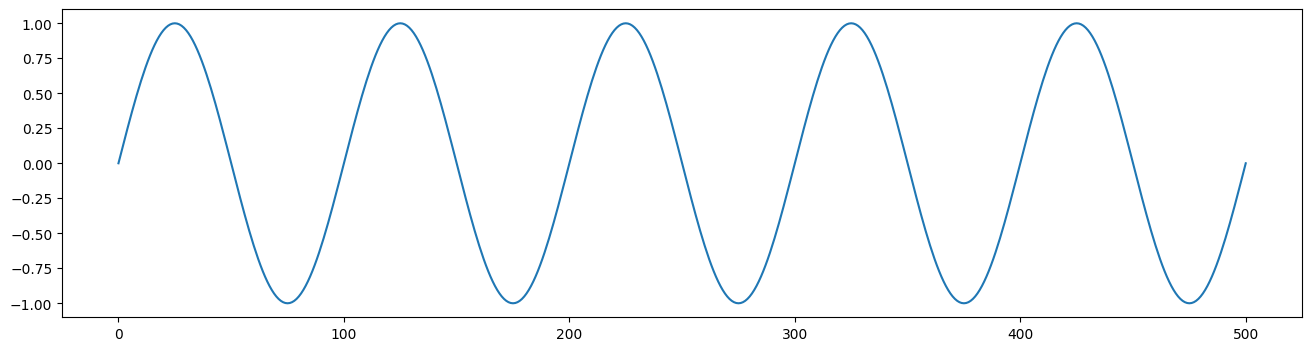

In [4]:
# sin波のグラフ表示
plt.figure(figsize=(16, 4))
plt.plot(t, dataset)

現実世界で観測されたデータを模して、ノイズを乗せます。ノイズは平均0、標準偏差0.1の正規分布に基づいています。

In [5]:
# ノイズを加える
dataset = sin(t) + np.random.normal(loc=0.0, scale=0.1, size=len(t))

結果は以下のようになります。これでデータセットができました。

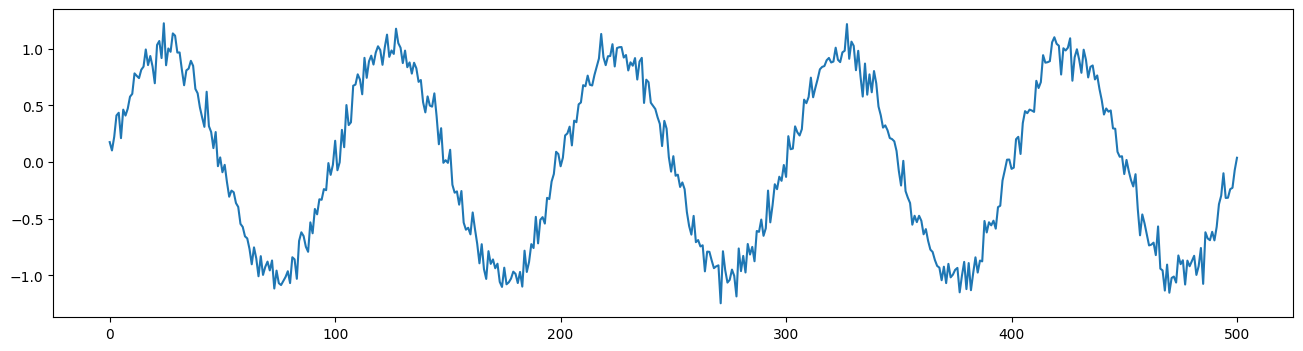

In [6]:
# ノイズを加えたsin波のグラフ表示
plt.figure(figsize=(16, 4))
plt.plot(t, dataset)

### 目的変数と説明変数の作成

次に、目的変数と説明変数を作成します。 まずは「入力データ長」を定義します。

In [7]:
# 入力データ長（順伝播の長さ）
T = 20

「過去の値」を説明変数、「予測したい値」を目的変数とします。入力データ長が20の場合、たとえば以下のようになります。

- 目的変数：No20、説明変数：No00～19
- 目的変数：No21、説明変数：No01～20
- 目的変数：No22、説明変数：No02～21
- …（以降も同様に続く）…

In [8]:
# 説明変数：目的変数の過去の情報
X = []
# 目的変数
Y = []

# 説明変数と目的変数の作成
for i in range(0, len(dataset) - T):
    X.append(dataset[i:i+T])
    Y.append(dataset[i+T])

データセットと比較して、XとYが正しく設定されていることを確認しましょう。

In [9]:
# XとYが正しく取得されていることを確認
#dataset[0:T+1]
dataset[1:T+2]

array([0.10280624, 0.22320703, 0.41147063, 0.43544569, 0.21128921,
       0.46313339, 0.41064357, 0.47143179, 0.57688665, 0.60218961,
       0.78285134, 0.76065088, 0.74113613, 0.81489957, 0.84238443,
       0.99373583, 0.85579085, 0.93613382, 0.84436691, 0.69575753,
       1.03394502])

In [11]:
#X[0]
X[1]

array([0.10280624, 0.22320703, 0.41147063, 0.43544569, 0.21128921,
       0.46313339, 0.41064357, 0.47143179, 0.57688665, 0.60218961,
       0.78285134, 0.76065088, 0.74113613, 0.81489957, 0.84238443,
       0.99373583, 0.85579085, 0.93613382, 0.84436691, 0.69575753])

In [12]:
#Y[0]
Y[1]

1.0339450206726672

学習用にreshapeします。

In [13]:
# 学習用にreshape(リストからnparrayへ)
X = np.array(X).reshape(-1, T, 1)
Y = np.array(Y).reshape(-1, 1)

In [14]:
# 形状を確認
print("Y=", Y.shape, ", X=", X.shape)

Y= (481, 1) , X= (481, 20, 1)


### データの分割

データの分割を行います。ただし今回は時系列データのため、データのシャッフルは行わず、前半70％を学習データとします。また、「学習・検証・テスト」の3つに分けています。

In [15]:
# データの分割（shuffleはしない）
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, shuffle=False)
X_train, X_valid, Y_train, Y_valid = train_test_split(X_train, Y_train, test_size=0.3, shuffle=False)

In [16]:
# 形状を確認
print("Y_train=", Y_train.shape, ", X_train=", X_train.shape)
print("Y_valid=", Y_valid.shape, ", X_valid=", X_valid.shape)
print("Y_test=", Y_test.shape, ", X_test=", X_test.shape)

Y_train= (235, 1) , X_train= (235, 20, 1)
Y_valid= (101, 1) , X_valid= (101, 20, 1)
Y_test= (145, 1) , X_test= (145, 20, 1)


### モデルの構築

Kerasでは、RNN層は SimpleRNN を使います。

In [17]:
# 出力数（回帰のため1）
OUT_SIZE = 1
# 隠れ層のユニット数
HIDE_SIZE = 100
# RNNの入力形状: 任意のタイムステップ長, 1つの特徴量
rnn_input_shape = (None, 1)

モデルを構築します。

In [18]:
# モデルの初期化
model = tf.keras.Sequential([
    # 入力層
    tf.keras.Input(shape=rnn_input_shape),
    # RNN層
    tf.keras.layers.SimpleRNN(HIDE_SIZE),
    # 出力層
    tf.keras.layers.Dense(OUT_SIZE, activation='linear')
])

# モデルの構築
model.compile(optimizer = tf.keras.optimizers.Adam(),
              loss='mean_squared_error')

続いて学習を実施します。

In [19]:
# 学習の実施
log = model.fit(X_train, Y_train, epochs=50, batch_size=32, verbose=True,
                callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss',
                                                         min_delta=0, patience=100,
                                                         verbose=1)],
                validation_data=(X_valid, Y_valid))

Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.3003 - val_loss: 0.0644
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0544 - val_loss: 0.0298
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0355 - val_loss: 0.0247
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0214 - val_loss: 0.0185
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0177 - val_loss: 0.0149
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0158 - val_loss: 0.0161
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0157 - val_loss: 0.0136
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0141 - val_loss: 0.0139
Epoch 9/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0137 - val_loss: 0.0135
Epoch 10/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0133 - val_loss: 0.0132
Epoch 11/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0135 - val_loss: 0.0132
Epoch 12/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0133 - val_loss: 0.0130
Epoch 13/50


モデルの構造を確認しましょう。10,301個のパラメータがあります。

In [20]:
# モデルの構造を表示
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 100)            │        10,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,905 (120.73 KB)

 Trainable params: 10,301 (40.24 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 20,604 (80.49 KB)

### 学習の経過の確認

学習の経過をグラフで確認しましょう。

Text(0, 0.5, 'crossentropy')

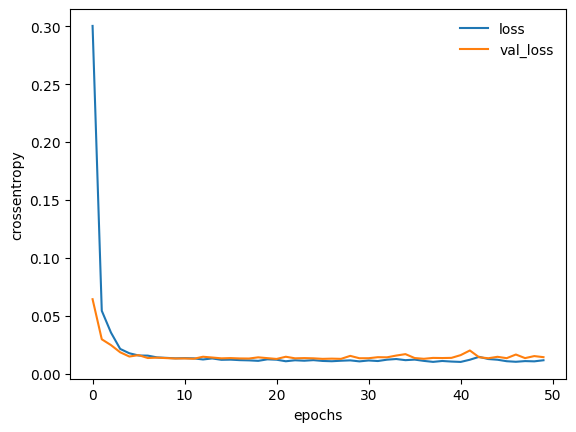

In [21]:
# 学習の経過をグラフ表示
plt.plot(log.history['loss'], label='loss')
plt.plot(log.history['val_loss'], label='val_loss')
plt.legend(frameon=False) # 凡例の表示
plt.xlabel("epochs")
plt.ylabel("crossentropy")

### テストデータによる評価

最後にテストデータによる評価を行います。

In [22]:
# 予測
pred_ys = model.predict(X_test)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


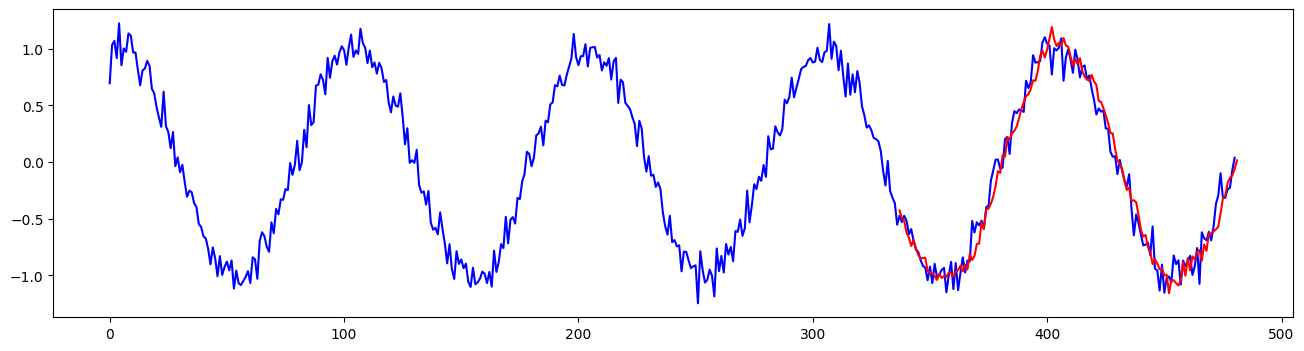

In [23]:
# 正解（青）と予測値（赤）との比較
plt.figure(figsize=(16, 4))
plt.plot(range(0, len(X)), Y, color='blue')
plt.plot(range(len(X_train)+len(X_valid)+1, len(X)+1), pred_ys, color='red')

MSE（平均二乗誤差）を算出してみましょう。

In [24]:
# MSEを算出
0.5 * ((Y_test - pred_ys) ** 2).sum()

0.9715989257332285

ノイズの影響を強く受けずに、本質的な波形を予測できていることがわかります。

## LSTMの実装

演習として、KerasによるLSTMモデルの実装を行ってみましょう。実装といっても、先ほどの「SimpleRNN」を「LSTM」に変更するだけです。データも、先ほどのものを利用します。

### モデルの構築

In [30]:
# モデルの初期化
model_lstm = tf.keras.Sequential([
    # 入力層
    tf.keras.Input(shape=rnn_input_shape),
    # RNN層
    tf.keras.layers.LSTM(HIDE_SIZE),
    # 出力層
    tf.keras.layers.Dense(OUT_SIZE, activation='linear')
])

# モデルの構築
model_lstm.compile(optimizer = tf.keras.optimizers.Adam(),
                   loss='mean_squared_error')

In [31]:
# 学習の実施
log_lstm = model_lstm.fit(X_train, Y_train, epochs=50, batch_size=32, verbose=True,
                          callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss',
                                                                      min_delta=0, patience=100,
                                                                      verbose=1)],
                          validation_data=(X_valid, Y_valid))

Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.2188 - val_loss: 0.1077
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0904 - val_loss: 0.0661
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0638 - val_loss: 0.0495
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0391 - val_loss: 0.0268
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0199 - val_loss: 0.0164
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0134 - val_loss: 0.0147
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0135 - val_loss: 0.0140
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0123 - val_loss: 0.0124
Epoch 9/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0126 - val_loss: 0.0122
Epoch 10/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0120 - val_loss: 0.0119
Epoch 11/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0117 - val_loss: 0.0123
Epoch 12/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0126 - val_loss: 0.0125
E

In [32]:
# モデルの構造を表示
model_lstm.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 100)            │        40,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,705 (479.32 KB)

 Trainable params: 40,901 (159.77 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 81,804 (319.55 KB)

### 学習の経過の確認

Text(0, 0.5, 'crossentropy')

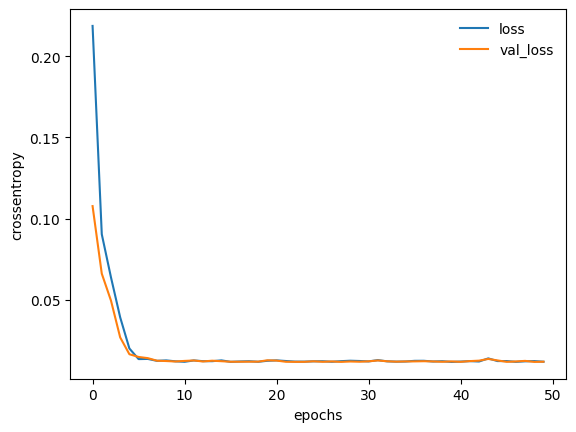

In [33]:
# 学習の経過をグラフ表示
plt.plot(log_lstm.history['loss'], label='loss')
plt.plot(log_lstm.history['val_loss'], label='val_loss')
plt.legend(frameon=False) # 凡例の表示
plt.xlabel("epochs")
plt.ylabel("crossentropy")

### テストデータによる評価

In [34]:
# 予測
pred_ys_lstm = model_lstm.predict(X_test)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


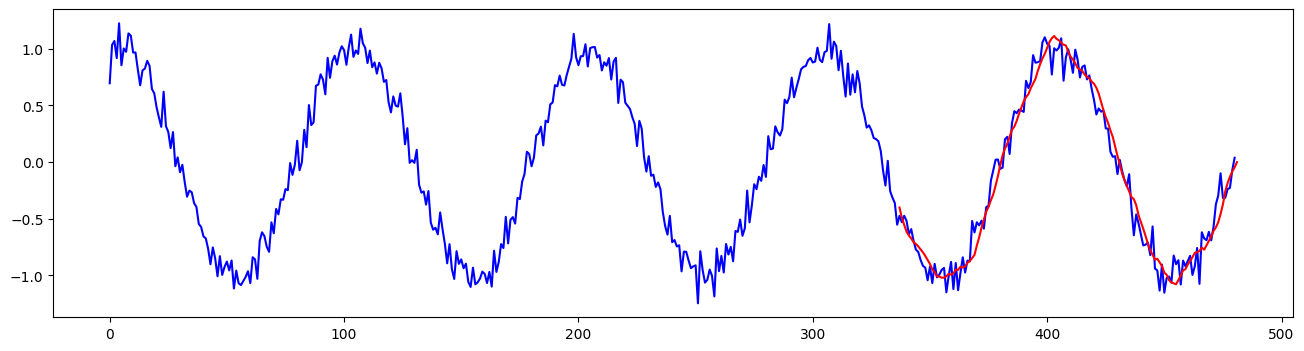

In [35]:
# 正解（青）と予測値（赤）との比較
plt.figure(figsize=(16, 4))
plt.plot(range(0, len(X)), Y, color='blue')
plt.plot(range(len(X_train)+len(X_valid)+1, len(X)+1), pred_ys_lstm, color='red')

予測結果は、以上のとおりです。長期依存性の傾向が反映され、全体としてノイズが除去された「綺麗な予測結果」を得られました